<br>

<div align="center">
<span style="font-size: 2.5em;">Dark Matter Halo Model Visualization</span>
<br>
<span style="font-size: 1.2em; color: gray;">Comparing velocity distributions and their impact on recoil spectra</span>
</div>

## Overview: Halo Models

This notebook visualizes different dark matter halo models used in data generation:

- **Default**: Standard Halo Model (SHM) with fixed WimPyDD default values
- **SHM**: SHM with sampled astrophysical parameters as nuisance parameters
- **X1 (Extreme High)**: SHM with +5σ parameter shifts (high velocities, proof-of-concept)
- **X2 (Extreme Low)**: SHM with -5σ parameter shifts (low velocities, proof-of-concept)
- **SHM++**: Extended model including non-isotropic "Gaia-sausage" component
- **LMC**: Model including contributions from the Large Magellanic Cloud

### Halo Model Parameters

| Halo Model | $v_0$ [km/s] | $v_{\rm esc}$ [km/s] | $v_{\rm sun}$ [km/s] | Reference |
|------------|-------------|----------------------|----------------------|-----------|
| **Default**   | 220 | 550 | [9, 12, 7] | WimPyDD (arXiv:2106.0627v1) |
| **SHM**       | 240 ± 8 | 528 ± 24.5 | [11.10 ± 1.23, 12.24 ± 2.05, 7.25 ± 0.62] | DMDD Conventions (arXiv:2105.00599v3) |
| **X1 (Extreme)** | 280 | 650.5 | [11.10, 12.24, 7.25] | +5σ variation (proof-of-concept) |
| **X2 (Extreme)** | 200 | 405.5 | [11.10, 12.24, 7.25] | -5σ variation (proof-of-concept) |
| **SHM++**     | 233 | 528 | [9, 12, 7] | Evans et al. (arXiv:1810.11468v2) |
| **LMC**       | — | — | — | Simulation (arXiv:2409.09119v1) |

**Notes**:
- Galactocentric Earth speed neglected (no annual modulation)
- **Default/SHM/X1/X2**: Analytical halo function evaluation
- **X1/X2**: Not physically realistic; used only for sensitivity analysis
- **SHM++**: Numerical integration via WimPyDD (no analytical solution)
- **LMC**: Pre-computed halo function from simulation data

In [ ]:
import os
desired_root_name = "xenon-sbi"   
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
    
import numpy as np
import matplotlib.pyplot as plt
import WimPyDD as WD

In [2]:
# Isoscalar SI Hamiltonian 
wc = {'1': lambda c_p=1e-9: [2*c_p,0]} # Isoscalar coupling -> cp=cn (in GeV^-2), c0=2cp, c1=0
SI = WD.eft_hamiltonian('SI', wc)
xenon_target = WD.target('Xe')

## 1. Standard Halo Model (SHM)

In [3]:
# =============================
# SHM PARAMETERS
# =============================

# Local DM density (not sampled - simple scaling factor)
rho_loc = 0.3  # GeV/cm^3

# Circular velocity (LSR velocity)
mu_v0, sigma_v0 = 240, 8  # km/s

# Galactic escape speed  
mu_vesc, sigma_vesc = 528, 24.5  # km/s

# Sun's peculiar velocity (Geneva-Copenhagen Survey, Schönrich et al. 2010)
v_sun_rot_mean = np.array([11.1, 12.24, 7.25])  # [U, V, W] in km/s
v_sun_rot_sigma_stat = np.array([0.720, 0.470, 0.365])         
v_sun_rot_sigma_sys = np.array([1.0, 2.0, 0.5])             
v_sun_rot_sigma = np.sqrt(v_sun_rot_sigma_stat**2 + v_sun_rot_sigma_sys**2)

In [4]:
# =============================
# HALO FUNCTION WRAPPER
# =============================

def streamed_halo(v0, vesc, v_sun_rot=None, n_vmin_bin=1000, **kwargs):
    """
    Compute streamed halo function for given astrophysical parameters.
    
    Parameters:
    -----------
    v0 : float
        Circular velocity [km/s]
    vesc : float
        Escape velocity [km/s]
    v_sun_rot : array_like, optional
        Sun's peculiar velocity [km/s]. Defaults to v_sun_rot_mean.
    n_vmin_bin : int
        Number of velocity bins
    **kwargs : dict
        Additional parameters for WD.streamed_halo_function
    
    Returns:
    --------
    vmin, delta_eta0 : arrays
        Minimum velocity and halo integral
    """
    if v_sun_rot is None:
        v_sun_rot = v_sun_rot_mean
        
    params = dict(
        v_rot_gal=np.array([0., v0, 0.]),
        v_esc_gal=vesc,
        v_sun_rot=v_sun_rot,
        n_vmin_bin=n_vmin_bin,
        yearly_modulation=False,
        delta_eta=True,
        full_year_sampling=False,
        recalculate=False,
    )
    params.update(kwargs)
    
    return WD.streamed_halo_function(**params)

Sampled v0 = 240.86 km/s
Sampled vesc = 540.47 km/s
Sampled v_sun_rot = [11.16, 13.86, 7.79] km/s


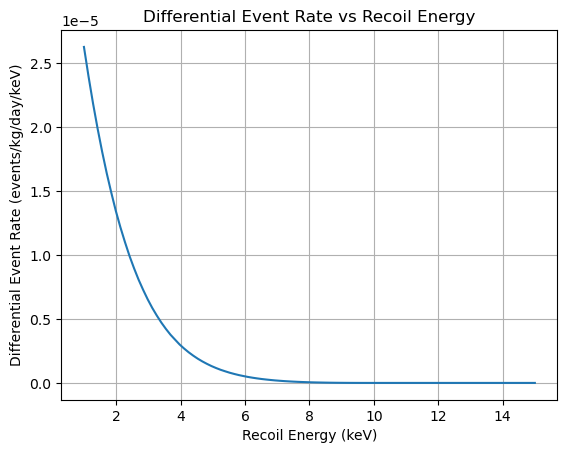

In [5]:
# =============================
# EXAMPLE: SINGLE REALIZATION
# =============================

# Sample parameters
v0_sample = np.random.normal(mu_v0, sigma_v0)
vesc_sample = np.random.normal(mu_vesc, sigma_vesc)
v_sun_rot_sample = np.random.normal(v_sun_rot_mean, v_sun_rot_sigma)

# Compute halo function
vmin, delta_eta0 = streamed_halo(v0_sample, vesc_sample, v_sun_rot_sample)

print(f"Sampled v0 = {v0_sample:.2f} km/s")
print(f"Sampled vesc = {vesc_sample:.2f} km/s")
print(f"Sampled v_sun_rot = [{v_sun_rot_sample[0]:.2f}, {v_sun_rot_sample[1]:.2f}, {v_sun_rot_sample[2]:.2f}] km/s")

# Compute differential rate
mchi = 10  # GeV
er_vec = np.linspace(1, 15, 100)
diff_rate = [WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0) for er in er_vec]

# Plot
plt.plot(er_vec, diff_rate)
plt.xlabel("Recoil Energy (keV)")
plt.ylabel("Differential Event Rate (events/kg/day/keV)")
plt.title("Differential Event Rate vs Recoil Energy")
plt.grid()
plt.show()

### Mass-Dependent Sensitivity to Halo Parameters

**Differential event rate**:
$$
\frac{dR}{dE_R} \propto \frac{\rho_\chi}{m_\chi} \, \sigma(E_R) \, \eta(v_{\min}), \quad \eta(v_{\min}) = \int_{v_{\min}}^{v_{\text{esc}}} \frac{f(v)}{v}\, d^3v
$$

**Minimum velocity**:
$$
v_{\min}(E_R) = \sqrt{\frac{m_T E_R}{2 \mu_T^2}}, \quad \mu_T = \frac{m_\chi m_T}{m_\chi + m_T}
$$

| DM Mass | Reduced Mass $\mu_T$ | $v_{\min}$ | Sampled Region | Sensitivity to $v_0, v_{\text{esc}}$ |
|---------|---------------------|------------|----------------|--------------------------------------|
| **Low**  | $m_\chi \ll m_T$ | $\propto 1/m_\chi$ (large) | High-velocity tail | **Strong** |
| **High** | $m_\chi \gg m_T$ | ≈ constant (small) | Maxwellian bulk | **Weak** |

**Key Insight**: Halo parameter uncertainties have the strongest impact on low-mass DM spectra, which probe the high-velocity tail. High-mass spectra are nearly indistinguishable across different halo assumptions.

In [ ]:
# =============================
# PLOT HALO PARAMETER VARIATIONS
# =============================

def plot_dru_variations(mchi, er_vec, n_realizations=10):
    """
    Plot multiple realizations showing the effect of halo parameter uncertainties.
    
    Parameters:
    -----------
    mchi : float
        DM mass [GeV]
    er_vec : array_like
        Recoil energies [keV]
    n_realizations : int
        Number of parameter samples to generate
    """
    all_spectra = []
    
    for _ in range(n_realizations):
        # Sample parameters
        v0_sample = np.random.normal(mu_v0, sigma_v0)
        vesc_sample = np.random.normal(mu_vesc, sigma_vesc)
        v_sun_rot_sample = np.random.normal(v_sun_rot_mean, v_sun_rot_sigma)

        # Compute halo function and spectrum
        vmin, delta_eta0 = streamed_halo(v0_sample, vesc_sample, v_sun_rot_sample)
        spectrum = [WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0) for er in er_vec]
        all_spectra.append(spectrum)

    all_spectra = np.array(all_spectra)
    mean_spectrum = np.mean(all_spectra, axis=0)

    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Linear scale
    for spectrum in all_spectra:
        ax1.plot(er_vec, spectrum, color='gray', alpha=0.3)
    ax1.plot(er_vec, mean_spectrum, color='orange', lw=2, label='Mean spectrum')
    ax1.set_xlabel("Recoil Energy (keV)")
    ax1.set_ylabel("Differential Event Rate (events/kg/day/keV)")
    ax1.set_title("Linear Scale")
    ax1.legend()
    ax1.grid()

    # Log scale
    for spectrum in all_spectra:
        ax2.plot(er_vec, spectrum, color='gray', alpha=0.3)
    ax2.plot(er_vec, mean_spectrum, color='orange', lw=2, label='Mean spectrum')
    ax2.set_xlabel("Recoil Energy (keV)")
    ax2.set_ylabel("Differential Event Rate (events/kg/day/keV)")
    ax2.set_title("Log Scale")
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid()

    plt.suptitle(f"Halo Parameter Uncertainties (m = {mchi} GeV)")
    plt.tight_layout()
    plt.show()

#### Low Mass ($m_\chi = 10$ GeV)

In [ ]:
mchi = 10 
er_vec=np.linspace(1,15,100) 
plot_dru_variations(mchi, er_vec, n_realizations=10)

#### Medium Mass ($m_\chi = 50$ GeV)

In [ ]:
mchi = 50 
er_vec=np.linspace(1,50,100) 
plot_dru_variations(mchi, er_vec, n_realizations=10)

#### High Mass ($m_\chi = 500$ GeV)

In [ ]:
mchi = 500 
er_vec=np.linspace(1,80,100) 
plot_dru_variations(mchi, er_vec, n_realizations=10)

## 2. Extreme SHM Variations (X1 & X2)

To demonstrate the conceptual impact of halo model uncertainties, we create extreme variations by shifting parameters by ±5 sigma from their mean values. These are not realistic models but serve as proof-of-concept for sensitivity analysis.

In [ ]:
# =============================
# EXTREME HALO VARIATIONS
# =============================

# SHM
v0_shm = mu_v0 
vesc_shm = mu_vesc 

# X1: High velocities (+5σ)
v0_x1 = mu_v0 + 5*sigma_v0 
vesc_x1 = mu_vesc + 5*sigma_vesc  #

# X2: Low velocities (-5σ)
v0_x2 = mu_v0 - 5*sigma_v0  
vesc_x2 = mu_vesc - 5*sigma_vesc 

# Compute halo functions
vmin_shm, delta_eta0_shm = streamed_halo(v0_shm, vesc_shm)
vmin_x1, delta_eta0_x1 = streamed_halo(v0_x1, vesc_x1)
vmin_x2, delta_eta0_x2 = streamed_halo(v0_x2, vesc_x2)

# Settings
mchi = 20  # GeV
er_vec = np.linspace(1, 60, 100)

# Compute spectra
diff_rate_shm = [WD.diff_rate(xenon_target, SI, mchi, er, vmin_shm, delta_eta0_shm) for er in er_vec]
diff_rate_x1 = [WD.diff_rate(xenon_target, SI, mchi, er, vmin_x1, delta_eta0_x1) for er in er_vec]
diff_rate_x2 = [WD.diff_rate(xenon_target, SI, mchi, er, vmin_x2, delta_eta0_x2) for er in er_vec]

# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.plot(er_vec, diff_rate_shm, label=r'SHM')
ax1.plot(er_vec, diff_rate_x1, label=r'X1 (high $v_0$, high $v_\mathrm{esc}$)')
ax1.plot(er_vec, diff_rate_x2, label=r'X2 (low $v_0$, low $v_\mathrm{esc}$)')
ax1.set_xlabel("Recoil Energy (keV)")
ax1.set_ylabel("Differential Event Rate (events/kg/day/keV)")
ax1.set_title("Linear Scale")
ax1.legend()
ax1.grid()

# Log scale
ax2.plot(er_vec, diff_rate_shm, label=r'SHM')
ax2.plot(er_vec, diff_rate_x1, label=r'X1 (high $v_0$, high $v_\mathrm{esc}$)')
ax2.plot(er_vec, diff_rate_x2, label=r'X2 (low $v_0$, low $v_\mathrm{esc}$)')
ax2.set_xlabel("Recoil Energy (keV)")
ax2.set_ylabel("Differential Event Rate (events/kg/day/keV)")
ax2.set_title("Log Scale")
ax2.set_yscale('log')
ax2.legend()
ax2.grid()

plt.suptitle(f"Extreme Halo Variations (m = {mchi} GeV)")
plt.tight_layout()
plt.show()

## 3. SHM++ (Gaia Sausage)

Extended halo model including a non-isotropic component from the Gaia-Enceladus/Sausage merger debris. Parameters from Evans et al. (2018).

In [ ]:
# =============================
# PLOT SHM++ vs SHM
# =============================

from data.compute_shmpp import shmpp_velocity_distribution

def plot_dru_shmpp_vs_shm(mchi, er_vec):
    """Compare SHM++ and SHM spectra (reproduces Fig. 3 from Evans et al. 2018)."""
    
    # SHM++ parameters
    v0 = 233.0
    vesc = 528.0
    v_sun_rot = np.array([11.1, 12.2, 7.3])
    eta = 0.2
    beta = 0.9

    # Compute SHM++ halo function
    vmin, delta_eta0 = WD.streamed_halo_function(
        velocity_distribution_gal=shmpp_velocity_distribution,   
        v_rot_gal=np.array([0., v0, 0.]),
        v_esc_gal=vesc,
        v_sun_rot=v_sun_rot,
        n_vmin_bin=1000,
        yearly_modulation=False,
        delta_eta=True,
        full_year_sampling=False,
        recalculate=False,
        outputfile="shmpp_1000.npy",
        v0=v0, v_esc=vesc, eta=eta, beta=beta   
    )
    diff_rate_shmpp = [WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0) for er in er_vec]

    # SHM (parameters from SHM++ paper)
    v0_shm = 220
    vesc_shm = 544
    vmin, delta_eta0 = WD.streamed_halo_function(
        v_rot_gal=np.array([0., v0_shm, 0.]), 
        v_esc_gal=vesc_shm
    )
    diff_rate_shm = [WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0) for er in er_vec]

    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Linear scale
    ax1.plot(er_vec, diff_rate_shm, label='SHM')
    ax1.plot(er_vec, diff_rate_shmpp, label='SHM++')
    ax1.set_xlabel("Recoil Energy (keV)")
    ax1.set_ylabel("Differential Event Rate (events/kg/day/keV)")
    ax1.set_title("Linear Scale")
    ax1.legend()
    ax1.grid()

    # Log scale
    ax2.plot(er_vec, diff_rate_shm, label='SHM')
    ax2.plot(er_vec, diff_rate_shmpp, label='SHM++')
    ax2.set_xlabel("Recoil Energy (keV)")
    ax2.set_ylabel("Differential Event Rate (events/kg/day/keV)")
    ax2.set_title("Log Scale")
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid()

    plt.suptitle(f"SHM vs SHM++ (m = {mchi} GeV)")
    plt.tight_layout()
    plt.show()

#### Low Mass ($m_\chi = 10$ GeV)

In [ ]:
mchi = 10 
er_vec=np.linspace(1,15,100) 
plot_dru_shmpp_vs_shm(mchi, er_vec)

#### Medium Mass ($m_\chi = 50$ GeV)

In [ ]:
mchi = 50 
er_vec=np.linspace(1,50,100) 
plot_dru_shmpp_vs_shm(mchi, er_vec)

#### High Mass ($m_\chi = 500$ GeV)

In [ ]:
mchi = 500 
er_vec=np.linspace(1,80,100) 
plot_dru_shmpp_vs_shm(mchi, er_vec)

## 4. LMC (Large Magellanic Cloud)

Halo model including the gravitational influence of the Large Magellanic Cloud, which significantly enhances the high-velocity tail of the local DM distribution.

**Data Source**: Pre-computed halo function from simulation with columns: `vmin`, `eta_median`, `eta_lower`, `eta_upper`, `h`

**Interpolation**: The raw data has limited sampling points. We use Piecewise Cubic Hermite Interpolation (PCHIP) to create a smooth, monotonic halo function.

In [ ]:
# =============================
# PLOT LMC vs SHM  
# =============================

def plot_dru_lmc_vs_shm(mchi, er_vec, interpolate_lmc=True):
    """Compare LMC and SHM spectra."""
    
    if interpolate_lmc:
        from scipy.interpolate import PchipInterpolator
        
        # Load raw LMC data
        data = np.loadtxt("WimPyDD/Halo_functions/lmc.txt")
        vmin_raw = data[:, 0]
        eta_median_raw = data[:, 1]

        # Interpolate for smoother function
        interp_eta = PchipInterpolator(vmin_raw, eta_median_raw)
        vmin_fine = np.linspace(vmin_raw.min(), vmin_raw.max(), 1000)
        eta_median_fine = interp_eta(vmin_fine)
        eta_median_fine = np.clip(eta_median_fine, 0, None)
        
        vmin = vmin_fine
        delta_eta0 = np.zeros_like(eta_median_fine)
        delta_eta0[1:] = eta_median_fine[:-1] - eta_median_fine[1:]
        
    else:
        # Use raw data without interpolation
        data = np.loadtxt("WimPyDD/Halo_functions/lmc.txt")
        vmin = data[:, 0]
        eta_median = data[:, 1]
        delta_eta0 = np.zeros_like(eta_median)
        delta_eta0[1:] = eta_median[:-1] - eta_median[1:]

    # Compute LMC spectrum
    diff_rate_lmc = [WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0) for er in er_vec]

    # Compute SHM spectrum
    vmin, delta_eta0 = streamed_halo(mu_v0, mu_vesc)
    diff_rate_shm = [WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0) for er in er_vec]

    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Linear scale
    ax1.plot(er_vec, diff_rate_shm, label='SHM')
    ax1.plot(er_vec, diff_rate_lmc, label='LMC')
    ax1.set_xlabel("Recoil Energy (keV)")
    ax1.set_ylabel("Differential Event Rate (events/kg/day/keV)")
    ax1.set_title("Linear Scale")
    ax1.legend()
    ax1.grid()

    # Log scale
    ax2.plot(er_vec, diff_rate_shm, label='SHM')
    ax2.plot(er_vec, diff_rate_lmc, label='LMC')
    ax2.set_xlabel("Recoil Energy (keV)")
    ax2.set_ylabel("Differential Event Rate (events/kg/day/keV)")
    ax2.set_title("Log Scale")
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid()

    plt.suptitle(f"SHM vs LMC (m = {mchi} GeV)")
    plt.tight_layout()
    plt.show()

#### Low Mass ($m_\chi = 10$ GeV)

In [ ]:
mchi = 10 
er_vec=np.linspace(1,15,100) 
plot_dru_lmc_vs_shm(mchi, er_vec, interpolate_lmc=True)

#### Medium Mass ($m_\chi = 50$ GeV)

In [ ]:
mchi = 50 
er_vec=np.linspace(1,50,100) 
plot_dru_lmc_vs_shm(mchi, er_vec, interpolate_lmc=True)

#### High Mass ($m_\chi = 500$ GeV)

In [ ]:
mchi = 500 
er_vec=np.linspace(1,80,100) 
plot_dru_lmc_vs_shm(mchi, er_vec, interpolate_lmc=True)

**Impact of LMC**: The Large Magellanic Cloud significantly boosts the high-velocity tail of the local DM distribution, causing a shift of ~150 km/s in the halo integral. This leads to notable shifts in direct detection exclusion limits toward smaller cross sections and lower DM masses.

## 5. Comprehensive Model Comparison

Side-by-side comparison of all halo models showing:
- **Left**: Recoil spectrum (linear scale)
- **Center**: Recoil spectrum (log scale)
- **Right**: Halo integral $\eta(v_{\min})$

In [ ]:
# =============================
# COMPREHENSIVE MODEL COMPARISON
# =============================

from scipy.interpolate import PchipInterpolator

def get_lmc_halo_function():
    """Load and interpolate LMC halo function."""
    data = np.loadtxt("WimPyDD/Halo_functions/lmc.txt")
    vmin_raw = data[:, 0]
    eta_median_raw = data[:, 1]

    interp_eta = PchipInterpolator(vmin_raw, eta_median_raw)
    vmin_fine = np.linspace(vmin_raw.min(), vmin_raw.max(), 1000)
    eta_median_fine = interp_eta(vmin_fine)
    eta_median_fine = np.clip(eta_median_fine, 0, None)

    delta_eta0 = np.zeros_like(eta_median_fine)
    delta_eta0[1:] = eta_median_fine[:-1] - eta_median_fine[1:]

    return vmin_fine, delta_eta0, eta_median_fine


def compute_spectrum(mchi, er_vec, vmin, delta_eta0):
    """Compute recoil spectrum for given halo function."""
    return np.array([
        WD.diff_rate(xenon_target, SI, mchi, er, vmin, delta_eta0)
        for er in er_vec
    ])

In [46]:
def plot_comparison_all_models(mchi, er_vec, include_extremes=False, sigma=None):
    models = {}

    # SHM
    vmin, delta_eta0 = streamed_halo(240.0, 528.0, v_sun_rot=np.array([11.1, 12.24, 7.25]))
    eta = np.cumsum(delta_eta0[::-1])[::-1]
    models["SHM"] = {
        "vmin": vmin, "delta_eta": delta_eta0, "eta": eta,
        "spec": compute_spectrum(mchi, er_vec, vmin, delta_eta0),
    }

    # SHM++
    vmin, delta_eta0 = WD.streamed_halo_function(outputfile="shmpp_1000.npy")
    eta = np.cumsum(delta_eta0[::-1])[::-1]
    models["SHM++"] = {
        "vmin": vmin, "delta_eta": delta_eta0, "eta": eta,
        "spec": compute_spectrum(mchi, er_vec, vmin, delta_eta0),
    }

    # LMC
    vmin, delta_eta0, eta = get_lmc_halo_function()
    models["LMC"] = {
        "vmin": vmin, "delta_eta": delta_eta0, "eta": eta,
        "spec": compute_spectrum(mchi, er_vec, vmin, delta_eta0),
    }

    # Extreme variations (optional)
    if include_extremes:
        vmin, delta_eta0 = WD.streamed_halo_function()
        eta = np.cumsum(delta_eta0[::-1])[::-1]
        models["Default"] = {
            "vmin": vmin, "delta_eta": delta_eta0, "eta": eta,
            "spec": compute_spectrum(mchi, er_vec, vmin, delta_eta0),
        }
        models = {"Default": models.pop("Default"), **models}

        vmin, delta_eta0 = streamed_halo(
            240.0 + sigma*8, 528 + sigma*24.5,
            v_sun_rot=np.array([11.1, 12.24, 7.25])
        )
        eta = np.cumsum(delta_eta0[::-1])[::-1]
        models["X1"] = {
            "vmin": vmin, "delta_eta": delta_eta0, "eta": eta,
            "spec": compute_spectrum(mchi, er_vec, vmin, delta_eta0),
        }

        vmin, delta_eta0 = streamed_halo(
            240.0 - sigma*8, 528 - sigma*24.5,
            v_sun_rot=np.array([11.1, 12.24, 7.25])
        )
        eta = np.cumsum(delta_eta0[::-1])[::-1]
        models["X2"] = {
            "vmin": vmin, "delta_eta": delta_eta0, "eta": eta,
            "spec": compute_spectrum(mchi, er_vec, vmin, delta_eta0),
        }

    # Color scheme
    if include_extremes:
        color_map = {
            "Default": "#969696",
            "SHM":     "#737373",
            "SHM++":   "#525252",
            "LMC":     "#252525",
            "X1":      "#2171b5",
            "X2":      "#6baed6",
        }
        linestyle_map = {k: "-" for k in color_map}
    else:
        color_map = {
            "SHM":   "#67000d",
            "SHM++": "#e34a33",
            "LMC":   "#dfa81e",
        }
        linestyle_map = {
            "SHM":   "--",
            "SHM++": "-",
            "LMC":   "-",
        }

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    ax_lin, ax_log, ax_eta = axes

    for name, data in models.items():
        color = color_map.get(name)
        ls = linestyle_map.get(name, "-")
        ax_lin.plot(er_vec, data["spec"], label=name, color=color,
                    linestyle=ls, linewidth=4)
        ax_log.semilogy(er_vec, data["spec"], label=name, color=color,
                        linestyle=ls, linewidth=4)
        ax_eta.semilogy(data["vmin"], data["eta"], label=name, color=color,
                        linestyle=ls, linewidth=4)

    # Linear recoil rate
    ax_lin.set_xlabel("Recoil Energy [keV]", fontsize=25)
    ax_lin.set_ylabel(r"$dR/dE$ [events/day/keV/kg]", fontsize=25)
    ax_lin.grid(alpha=0.3, linewidth=0.8)
    ax_lin.legend(fontsize=23)
    ax_lin.tick_params(labelsize=23)
    ax_lin.yaxis.get_offset_text().set_fontsize(21)

    # Log recoil rate
    ax_log.set_xlabel("Recoil Energy [keV]", fontsize=25)
    ax_log.set_ylabel(r"$dR/dE$ [events/day/keV/kg]", fontsize=25)
    ax_log.grid(alpha=0.3, which="major", linewidth=0.8)
    ax_log.tick_params(labelsize=23)
    ax_log.yaxis.get_offset_text().set_fontsize(21)

    # Halo integral (linear x-axis)
    ax_eta.set_xlabel(r"$v_{\min}$ [km/s]", fontsize=25)
    ax_eta.set_ylabel(r"$\eta(v_{\min})$", fontsize=25)
    ax_eta.grid(alpha=0.3, which="major", linewidth=0.8)
    ax_eta.set_xticks([250, 500, 750, 1000])
    ax_eta.set_yticks([1e-4, 1e-6, 1e-8, 1e-10])
    ax_eta.tick_params(labelsize=23)
    ax_eta.yaxis.get_offset_text().set_fontsize(21)

    fig.suptitle(
        rf"Recoil rates and halo integral for different halo models "
        rf"($m_\chi = {mchi}~\mathrm{{GeV}}$, $c_p = 10^{{-9}}~\mathrm{{GeV}}^{{-2}}$)",
        fontsize=32, y=0.97
    )

    plt.tight_layout()
    pdf_path = f"figures/chap3/recoil_rate_halos_m{mchi}_{include_extremes}.pdf"
    fig.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Figure saved to {pdf_path}")
    plt.show()

### Realistic Models Only

#### Low Mass ($m_\chi = 10$ GeV)

loading shmpp_1000.npy
type: print(np.load('WimPyDD/Halo_functions/shmpp_1000.npy',allow_pickle=True)[-1]) to get input parameters
Figure saved to figures/chap3/recoil_rate_halos_m10_False.pdf


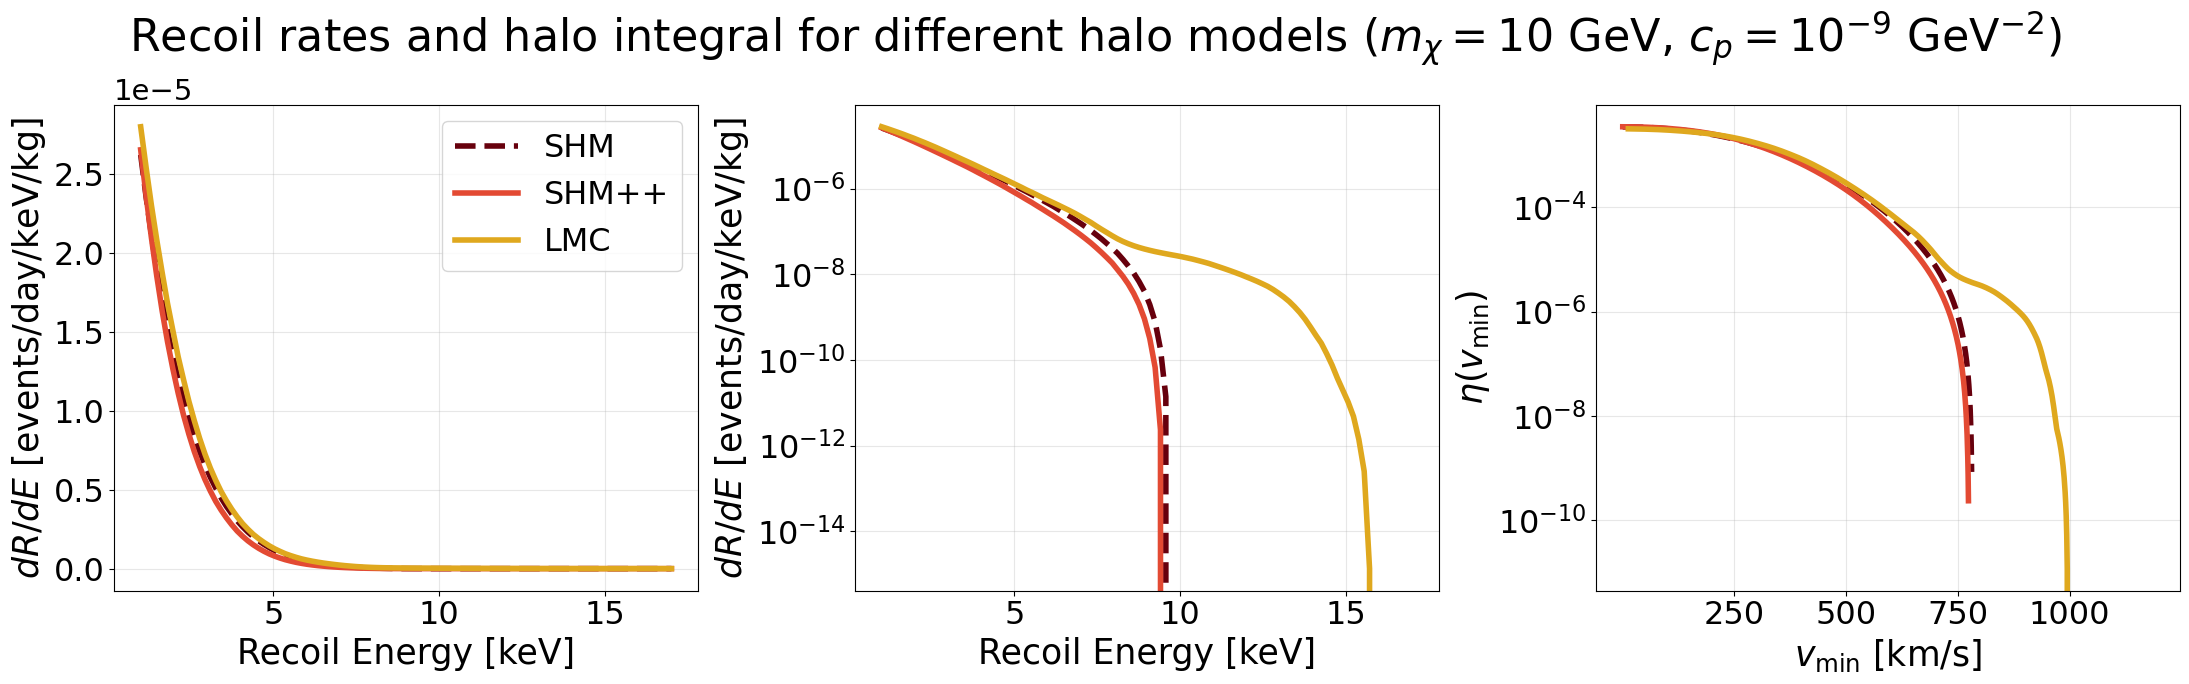

In [47]:
mchi = 10 
er_vec=np.linspace(1,17,100) 
plot_comparison_all_models(mchi, er_vec, include_extremes=False)

#### Medium Mass ($m_\chi = 70$ GeV)

loading shmpp_1000.npy
type: print(np.load('WimPyDD/Halo_functions/shmpp_1000.npy',allow_pickle=True)[-1]) to get input parameters
Figure saved to figures/chap3/recoil_rate_halos_m70_False.pdf


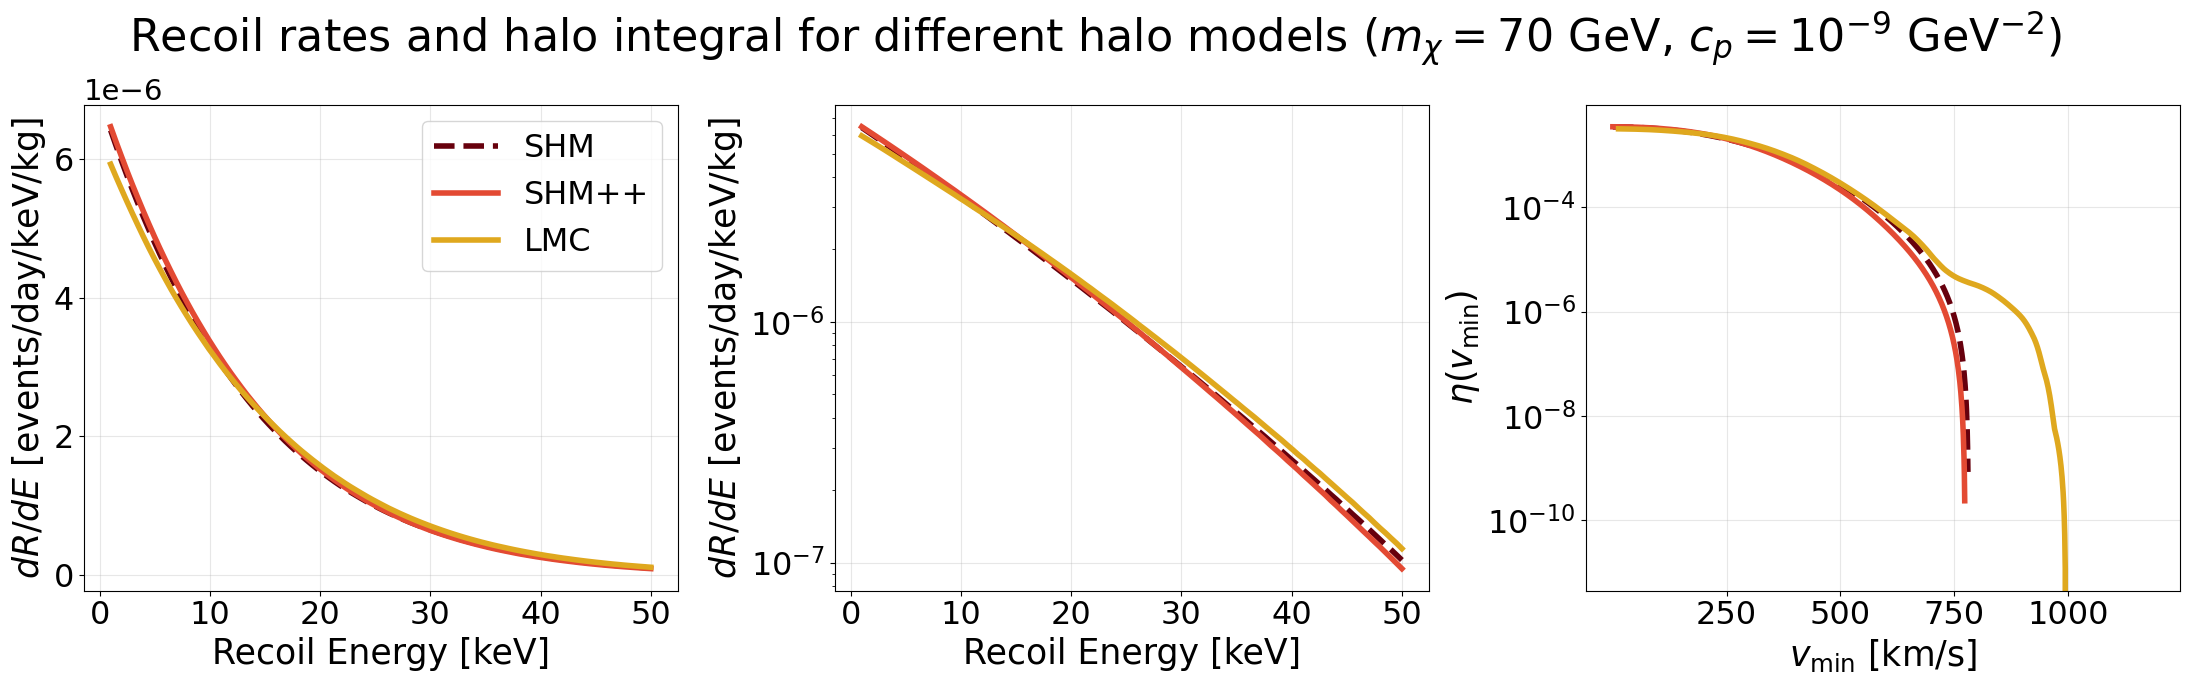

In [48]:
mchi = 70 
er_vec=np.linspace(1,50,100) 
plot_comparison_all_models(mchi, er_vec, include_extremes=False)

#### High Mass ($m_\chi = 200$ GeV)

loading shmpp_1000.npy
type: print(np.load('WimPyDD/Halo_functions/shmpp_1000.npy',allow_pickle=True)[-1]) to get input parameters
Figure saved to figures/chap3/recoil_rate_halos_m200_False.pdf


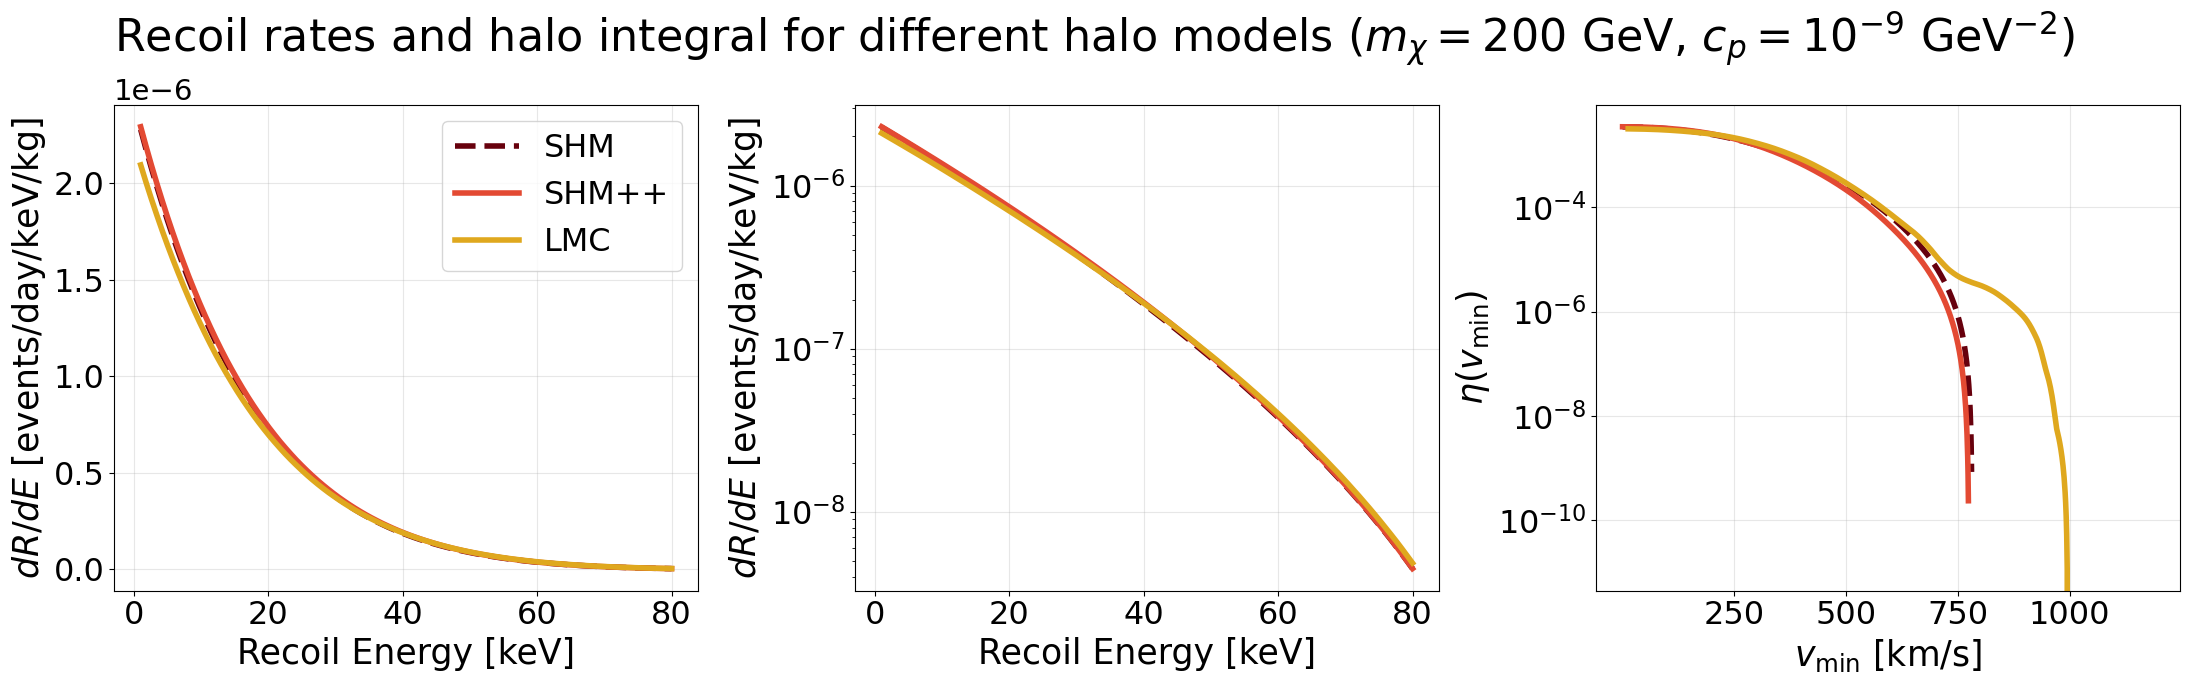

In [49]:
mchi = 200 
er_vec=np.linspace(1,80,100) 
plot_comparison_all_models(mchi, er_vec, include_extremes=False)

### Including Extreme Variations (X1 & X2)

#### Low Mass ($m_\chi = 10$ GeV)

loading shmpp_1000.npy
type: print(np.load('WimPyDD/Halo_functions/shmpp_1000.npy',allow_pickle=True)[-1]) to get input parameters
Figure saved to figures/chap3/recoil_rate_halos_m10_True.pdf


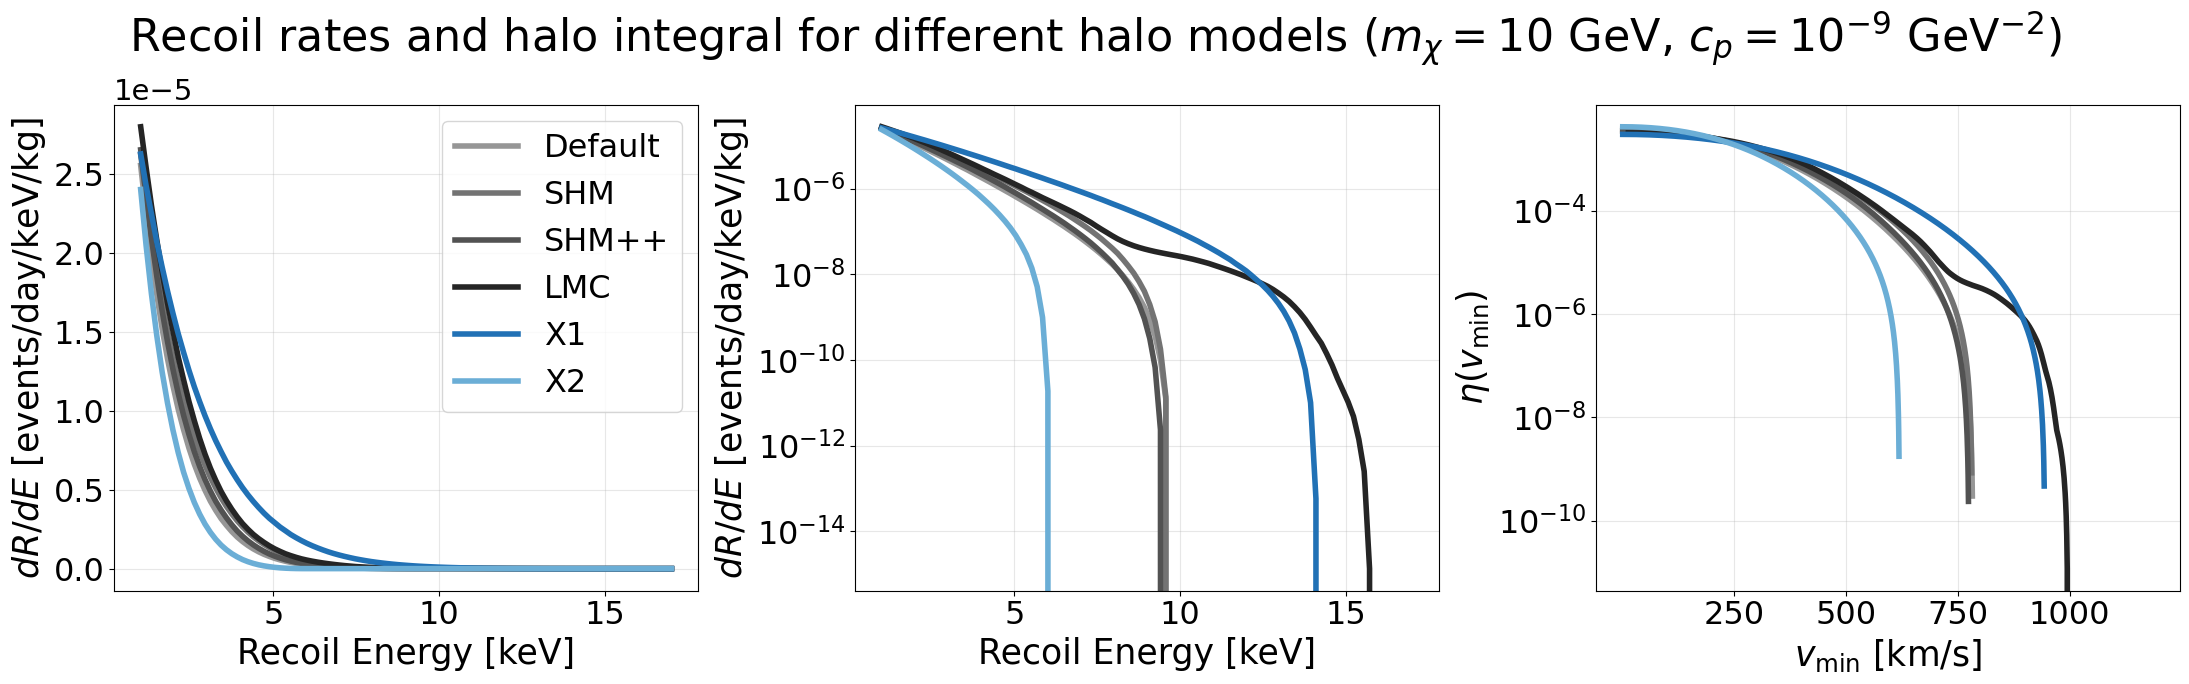

In [50]:
mchi = 10 
er_vec=np.linspace(1,17,100) 
plot_comparison_all_models(mchi, er_vec, include_extremes=True, sigma=5)

#### Medium Mass ($m_\chi = 70$ GeV)

loading shmpp_1000.npy
type: print(np.load('WimPyDD/Halo_functions/shmpp_1000.npy',allow_pickle=True)[-1]) to get input parameters
Figure saved to figures/chap3/recoil_rate_halos_m70_True.pdf


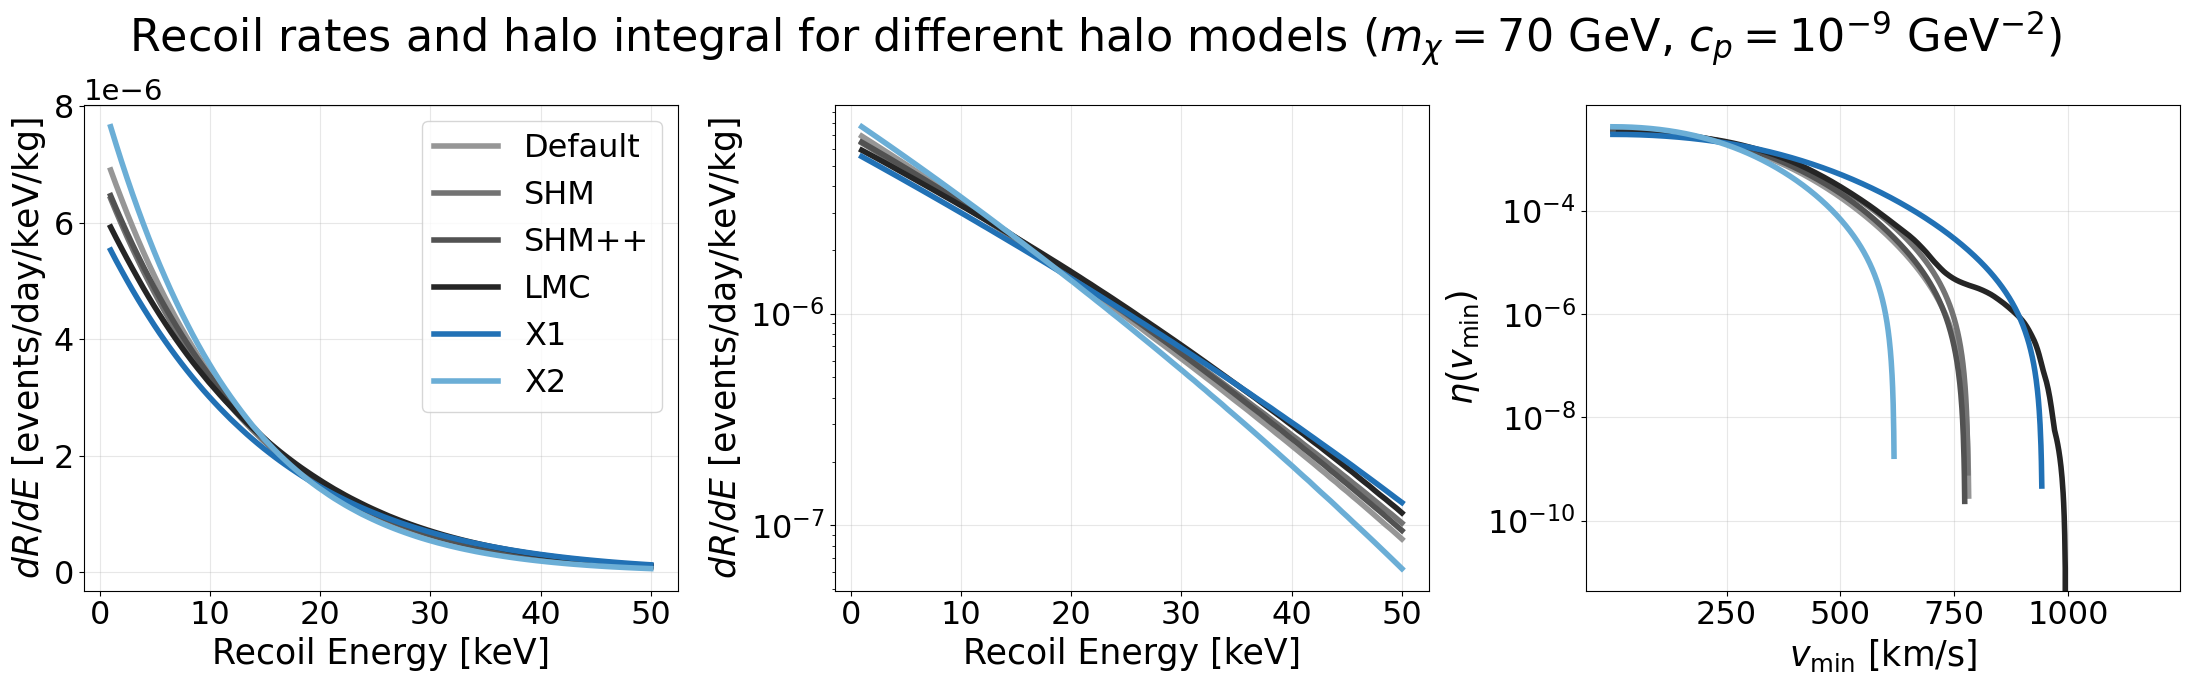

In [51]:
mchi = 70 
er_vec=np.linspace(1,50,100) 
plot_comparison_all_models(mchi, er_vec, include_extremes=True, sigma=5)

#### High Mass ($m_\chi = 200$ GeV)

loading shmpp_1000.npy
type: print(np.load('WimPyDD/Halo_functions/shmpp_1000.npy',allow_pickle=True)[-1]) to get input parameters
Figure saved to figures/chap3/recoil_rate_halos_m200_True.pdf


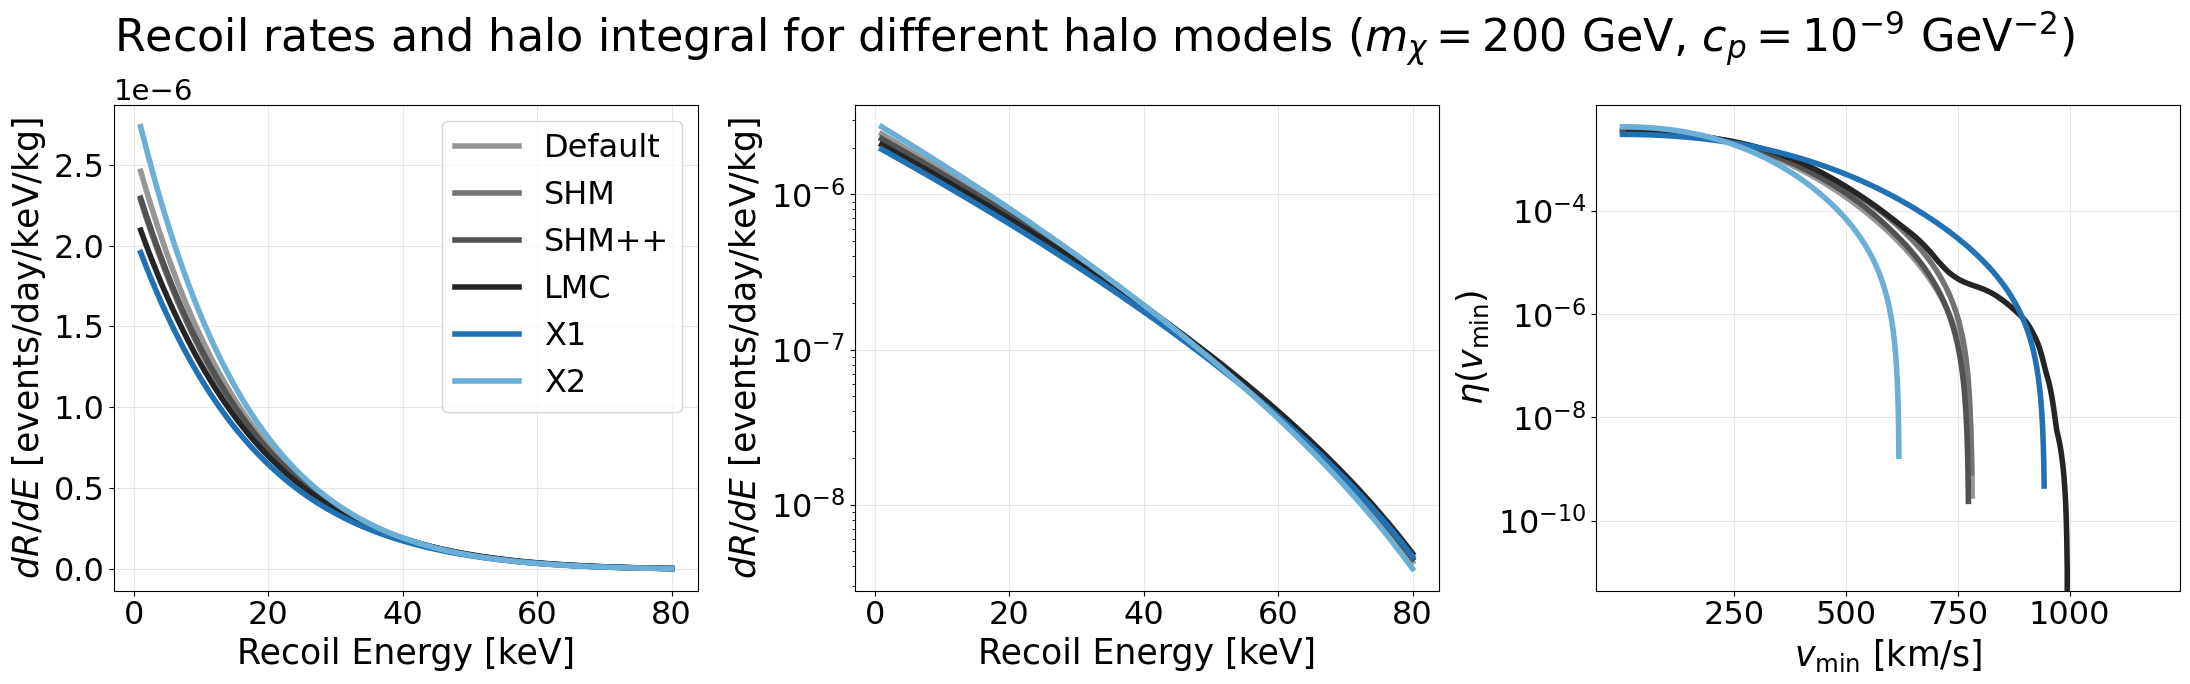

In [52]:
mchi = 200 
er_vec=np.linspace(1,80,100) 
plot_comparison_all_models(mchi, er_vec, include_extremes=True, sigma=5)